## Imports and load data

In [21]:
import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import scanpy as sc

import os
main_path = os.getcwd()

In [22]:
adata = ad.read_h5ad(os.path.join(main_path, 'data/GRI_CRC_BIG_adata_ssl_leiden_224px_fold0.h5ad'))

ssl_adata_train = ad.read_h5ad(os.path.join(main_path, 'data/ssl_adata/gri-crc/adata-train.hdf5'))
ssl_adata_valid = ad.read_h5ad(os.path.join(main_path, 'data/ssl_adata/gri-crc/adata-valid.hdf5'))

/mnt/cephfs/home/users/krakovic/.conda/envs/scpy/lib/python3.10/site-packages/anndata/_core/anndata.py:183: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [43]:
adata.obs

,TMA_group,TMA_num,image,image_path,CellX,CellY,area,compartment,envelope_left,envelope_top,...,t_CellX,t_CellY,orig_phenotype,y_start,y_stop,x_start,x_stop,leiden,tile,phenotype
0,TMA1,TMA1A,"GRI-CRC-TMA 1A 9_Core[1,1,1]_177350",E:\CRC Component Images\Included\1A\GRI-CRC-TM...,9428.643554,-31125.962412,150.282984,tumour,9.421697,-31.117715,...,423.604896,-98.312173,panCK,0.0000,111.3728,111.3728,222.7456,NaN,0_224_224_448,panCK
1,TMA1,TMA1A,"GRI-CRC-TMA 1A 9_Core[1,1,1]_177350",E:\CRC Component Images\Included\1A\GRI-CRC-TM...,9422.054304,-31138.536692,109.746126,stroma,9.415731,-31.132630,...,410.352180,-123.602357,Unclassifiable,0.0000,111.3728,111.3728,222.7456,NaN,0_224_224_448,Unclassifiable
2,TMA1,TMA1A,"GRI-CRC-TMA 1A 9_Core[1,1,1]_177350",E:\CRC Component Images\Included\1A\GRI-CRC-TM...,9402.615208,-31146.075708,124.823860,tumour,9.395844,-31.139093,...,371.255045,-138.765303,panCK,0.0000,111.3728,111.3728,222.7456,NaN,0_224_224_448,panCK
3,TMA1,TMA1A,"GRI-CRC-TMA 1A 9_Core[1,1,1]_177350",E:\CRC Component Images\Included\1A\GRI-CRC-TM...,9411.116201,-31146.620914,42.019913,tumour,9.408274,-31.142076,...,388.352777,-139.861854,panCK,0.0000,111.3728,111.3728,222.7456,NaN,0_224_224_448,panCK
4,TMA1,TMA1A,"GRI-CRC-TMA 1A 9_Core[1,1,1]_177350",E:\CRC Component Images\Included\1A\GRI-CRC-TM...,9392.266016,-31154.884903,88.241818,tumour,9.387393,-31.148539,...,350.440096,-156.482911,panCK,0.0000,111.3728,111.3728,222.7456,NaN,0_224_224_448,panCK
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1575274,TMA4,TMA4C,"GRI-CRC-TMA 4C 9_Core[1,8,3]_2070339",E:\CRC Component Images\Included\4C\GRI-CRC-TM...,15521.796298,-30151.267125,59.075054,stroma,15.517198,-30.146796,...,944.829239,-1370.043293,panCK,668.2368,779.6096,445.4912,556.8640,NaN,1344_1568_896_1120,panCK
1575275,TMA4,TMA4C,"GRI-CRC-TMA 4C 9_Core[1,8,3]_2070339",E:\CRC Component Images\Included\4C\GRI-CRC-TM...,15490.093387,-30152.994180,68.467741,stroma,15.485379,-30.147293,...,881.066346,-1373.516854,panCK,668.2368,779.6096,334.1184,445.4912,NaN,1344_1568_672_896,panCK
1575276,TMA4,TMA4C,"GRI-CRC-TMA 4C 9_Core[1,8,3]_2070339",E:\CRC Component Images\Included\4C\GRI-CRC-TM...,15540.174275,-30151.826600,5.190695,Clear,15.539073,-30.150276,...,981.792187,-1371.168544,Unclassifiable,668.2368,779.6096,445.4912,556.8640,NaN,1344_1568_896_1120,Unclassifiable
1575277,TMA4,TMA4C,"GRI-CRC-TMA 4C 9_Core[1,8,3]_2070339",E:\CRC Component Images\Included\4C\GRI-CRC-TM...,15476.352591,-30163.641327,125.812563,stroma,15.469967,-30.155745,...,853.429990,-1394.931068,panCK,668.2368,779.6096,334.1184,445.4912,NaN,1344_1568_672_896,panCK


In [23]:
ssl_adata_train.obs['leiden'].nunique()

20

In [24]:
clinical = pd.read_spss(os.path.join(main_path, 'data/metadata/GRI TMA database_2025.sav'))

In [25]:
clinical['CMS_caller_LS'].isna().value_counts()

True     557
False    230
Name: CMS_caller_LS, dtype: int64

## Pre-processing

In [26]:
def write_tile_label(row):
    y_start = int(np.round(row['y_start'] / 0.4972, 0))
    y_stop = int(np.round(row['y_stop'] / 0.4972, 0))
    x_start = int(np.round(row['x_start'] / 0.4972, 0))
    x_stop = int(np.round(row['x_stop'] / 0.4972, 0))

    return "_".join([str(x) for x in [y_start, y_stop, x_start, x_stop]])

adata.obs['tile'] = adata.obs.apply(lambda row: write_tile_label(row), axis=1)

In [27]:
def assign_tumour(row):
    if row['orig_phenotype'] == 'Unclassifiable' and row['compartment'] == 'tumour':
        return 'panCK'
    else:
        return row['orig_phenotype']
    
adata.obs = adata.obs.rename(columns={'phenotype':'orig_phenotype'})
adata.obs['phenotype'] = adata.obs.apply(lambda row: assign_tumour(row), axis=1)

In [28]:
adata.obs[adata.obs['orig_phenotype'] == 'Unclassifiable']['compartment'].value_counts()

stroma    251662
Clear      16731
tumour         0
Name: compartment, dtype: int64

In [44]:
leiden_clusters = list(adata.obs['leiden'].unique())
all_cores = list(adata.obs['core'].unique())

phenotype_counts_by_tile = adata.obs.groupby(['core', 'tile'])['orig_phenotype'].value_counts()
phenotype_counts_by_tile.name = 'count'
phenotype_counts_by_tile = phenotype_counts_by_tile.reset_index()

phenotype_counts_by_tile

,core,tile,orig_phenotype,count
0,1A-1-1,0_224_1120_1344,panCK,28
1,1A-1-1,0_224_1120_1344,CD68,2
2,1A-1-1,0_224_1120_1344,Unclassifiable,2
3,1A-1-1,0_224_1120_1344,CD3-CD8,0
4,1A-1-1,0_224_1120_1344,CD3-FOXP3,0
...,...,...,...,...
254571,4C-22-2070295,896_1120_896_1120,CD68,1
254572,4C-22-2070295,896_1120_896_1120,CD3-CD8,0
254573,4C-22-2070295,896_1120_896_1120,CD3-FOXP3,0
254574,4C-22-2070295,896_1120_896_1120,CD3-other,0


In [45]:
phenotype_counts_by_cluster = phenotype_counts_by_tile.merge(adata.obs[['core', 'tile', 'leiden']], on=['core', 'tile'], how='left').drop_duplicates()
phenotype_counts_by_cluster

,core,tile,orig_phenotype,count,leiden
0,1A-1-1,0_224_1120_1344,panCK,28,15
32,1A-1-1,0_224_1120_1344,CD68,2,15
64,1A-1-1,0_224_1120_1344,Unclassifiable,2,15
96,1A-1-1,0_224_1120_1344,CD3-CD8,0,15
128,1A-1-1,0_224_1120_1344,CD3-FOXP3,0,15
...,...,...,...,...,...
11026543,4C-22-2070295,896_1120_896_1120,CD68,1,NaN
11026625,4C-22-2070295,896_1120_896_1120,CD3-CD8,0,NaN
11026707,4C-22-2070295,896_1120_896_1120,CD3-FOXP3,0,NaN
11026789,4C-22-2070295,896_1120_896_1120,CD3-other,0,NaN


### Distribution of cell counts per tile (raw)

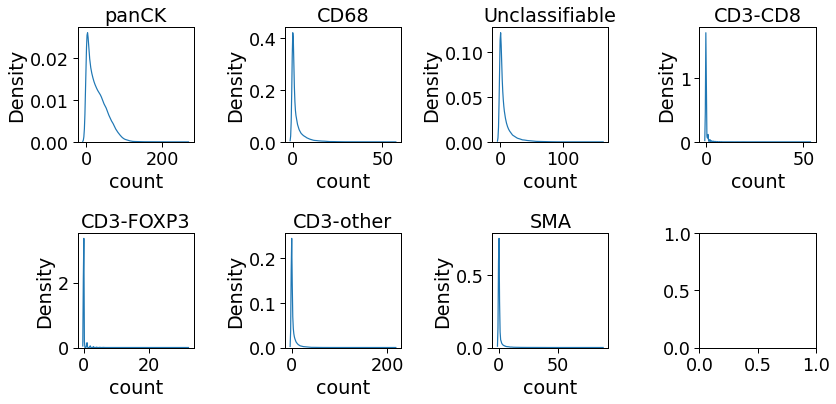

In [47]:
fig, axs = plt.subplots(nrows=2, ncols=4, figsize=(12,6))
axs = axs.flatten()

for i, phenotype in enumerate(phenotype_counts_by_cluster['orig_phenotype'].unique()):
    sns.kdeplot(phenotype_counts_by_cluster[phenotype_counts_by_cluster['orig_phenotype'] == phenotype], x='count', ax=axs[i])
    axs[i].set_title(phenotype)

plt.tight_layout()
plt.show()

In [48]:
phenotype_counts_by_cluster['log10_count'] = np.log10(phenotype_counts_by_cluster['count'] + 1)

### Distribution of cell counts per tile (log10)

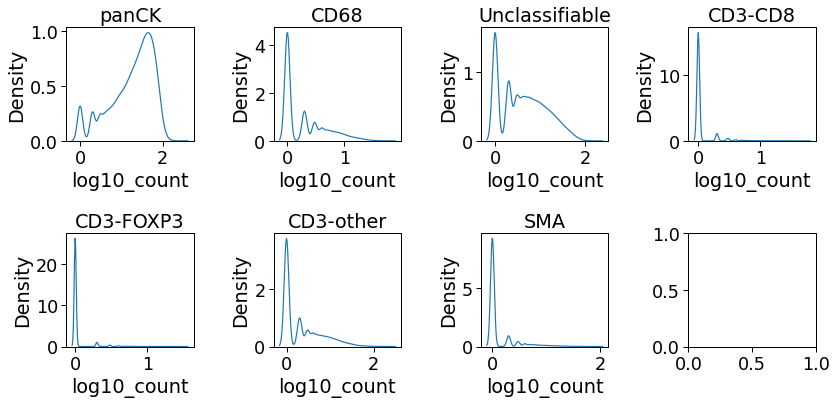

In [49]:
fig, axs = plt.subplots(nrows=2, ncols=4, figsize=(12,6))
axs = axs.flatten()

for i, phenotype in enumerate(phenotype_counts_by_cluster['orig_phenotype'].unique()):
    sns.kdeplot(phenotype_counts_by_cluster[phenotype_counts_by_cluster['orig_phenotype'] == phenotype], x='log10_count', ax=axs[i])
    axs[i].set_title(phenotype)

plt.tight_layout()
plt.show()

## Mean cell counts per cluster

In [50]:
mean_counts_by_cluster = phenotype_counts_by_cluster.groupby(['leiden', 'orig_phenotype'])['log10_count'].agg('mean').reset_index()
mean_counts_by_cluster = mean_counts_by_cluster.pivot(columns=['orig_phenotype'], index='leiden')
mean_counts_by_cluster.columns = [col[1] for col in mean_counts_by_cluster.columns]
mean_counts_by_cluster

,CD3-CD8,CD3-FOXP3,CD3-other,CD68,SMA,Unclassifiable,panCK
leiden,,,,,,,
0,0.041148,0.055690,0.438005,0.437006,0.284100,0.539191,1.568781
1,0.059402,0.021239,0.403759,0.361458,0.096204,0.977040,1.476894
2,0.063655,0.045297,0.463466,0.430353,0.190715,0.609425,1.487855
3,0.048377,0.029882,0.346725,0.372890,0.159154,0.749975,1.612624
4,0.031984,0.024176,0.290234,0.258492,0.104440,0.710545,1.607091
5,0.075950,0.014672,0.385480,0.337484,0.048711,1.260768,1.295479
6,0.077331,0.027572,0.483853,0.400885,0.111710,0.919961,1.376942
7,0.096792,0.017244,0.397270,0.373186,0.057977,1.024771,1.361843
8,0.054276,0.019418,0.347571,0.265834,0.055265,1.156130,1.461822


In [35]:
# mean_counts_by_cluster.to_csv(os.path.join(main_path, 'data/results/gri-log10-counts-by-cluster.csv'))

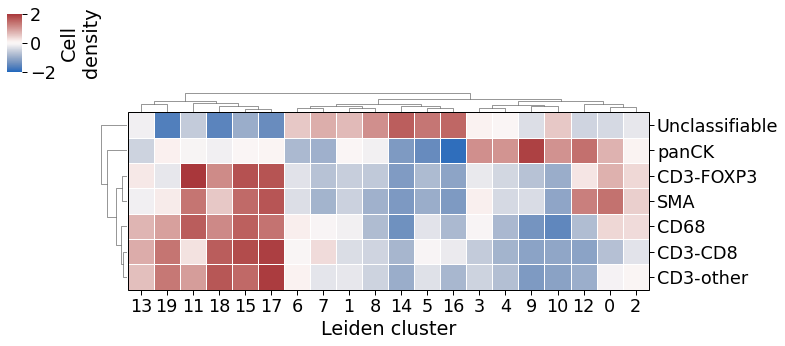

In [51]:
from matplotlib.patches import Rectangle

sns.set_context("paper", font_scale=2.0)

g = sns.clustermap(mean_counts_by_cluster.T,
               z_score=0,
               vmin=-2, vmax=2,
               cmap='vlag',
               linewidth=.5,
               dendrogram_ratio=(.05, .1),
               cbar_pos=(-0.1,1,.02,.2),
               cbar_kws={'label':'Cell\ndensity'},
               figsize=(10,4)
               )

ncols = mean_counts_by_cluster.T.shape[0]
nrows = mean_counts_by_cluster.T.shape[1]

rect = Rectangle(
    xy=(0, 0),  # Lower left corner
    width=nrows,
    height=ncols,
    fill=False,
    edgecolor='black',
    linewidth=1,
    clip_on=False
)

g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), rotation=0)
g.ax_heatmap.set_xlabel('Leiden cluster')
g.ax_heatmap.add_patch(rect)

# plt.savefig('/Users/Kai/GRI_CRC/clusters_vs_cell_density.pdf', dpi=300, bbox_inches='tight', pad_inches=.1)


## UMAPs

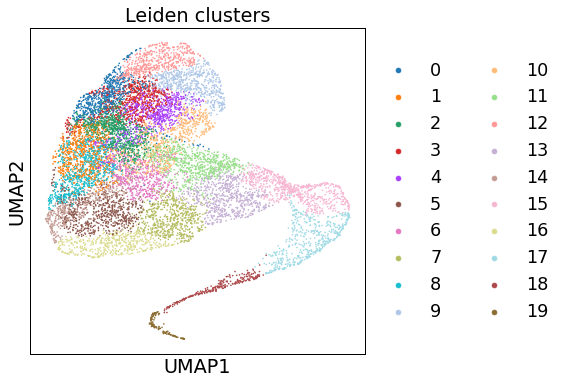

In [38]:
fig, ax = plt.subplots(figsize=(6,6))
sc.pl.umap(ssl_adata_train, color='leiden', show=False, ax=ax)
ax.set_title('Leiden clusters')
plt.show()

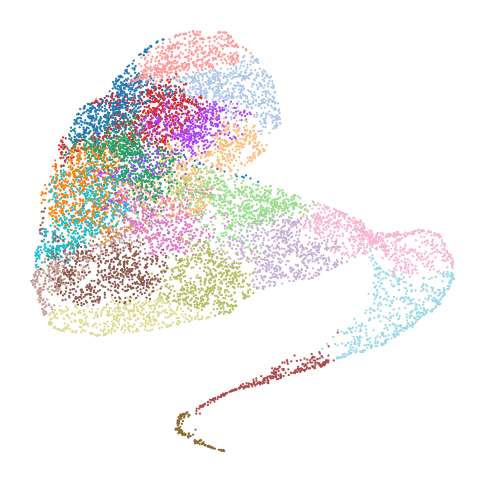

In [ ]:
fig, ax = plt.subplots(figsize=(6,6))
sc.pl.umap(ssl_adata_train, color='leiden', show=False, ax=ax)
ax.set_title(None)
ax.axis('off')
ax.get_legend().remove()
plt.show()

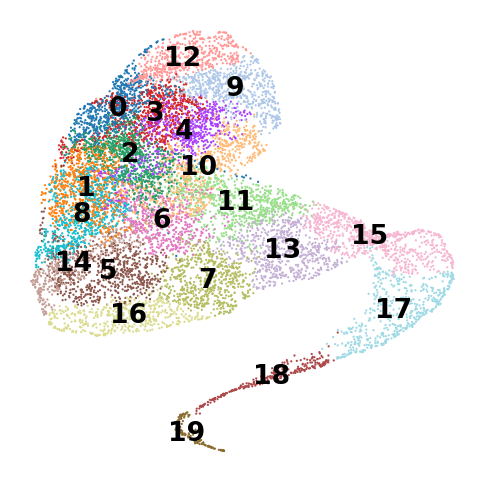

In [ ]:
fig, ax = plt.subplots(figsize=(6,6))
sc.pl.umap(ssl_adata_train, color='leiden', legend_loc='on data', show=False, ax=ax)
ax.set_title(None)
ax.axis('off')
plt.show()

### Scale values

In [39]:
mean_counts_by_cluster

,CD3-CD8,CD3-FOXP3,CD3-other,CD68,SMA,Unclassifiable,panCK
leiden,,,,,,,
0,0.418220,0.407815,0.737726,0.686059,0.705165,0.661505,1.571446
1,0.485119,0.370662,0.692313,0.636926,0.504380,1.015292,1.480380
2,0.495666,0.445644,0.765301,0.677270,0.612002,0.726622,1.492396
3,0.494193,0.384888,0.629202,0.602009,0.538849,0.829804,1.612624
4,0.423699,0.408018,0.591023,0.539767,0.480110,0.804588,1.613640
5,0.476413,0.400241,0.671869,0.619514,0.439519,1.283750,1.313394
6,0.476958,0.408688,0.782853,0.641835,0.537494,0.981933,1.382961
7,0.485857,0.392389,0.679139,0.612408,0.467465,1.094229,1.382088
8,0.520723,0.412949,0.611726,0.542728,0.496604,1.183966,1.472205


In [40]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled_counts_by_cluster = mean_counts_by_cluster.copy(deep=True)

for column in mean_counts_by_cluster.columns:
    scaled_counts_by_cluster[column] = scaler.fit_transform(mean_counts_by_cluster[column].values.reshape(-1,1))


In [41]:
for column in scaled_counts_by_cluster.columns:
    ssl_adata_train.obs[column] = ssl_adata_train.obs['leiden'].apply(lambda x: scaled_counts_by_cluster.loc[str(x), column])
    ssl_adata_train.obs[column] = ssl_adata_train.obs[column].astype('float')

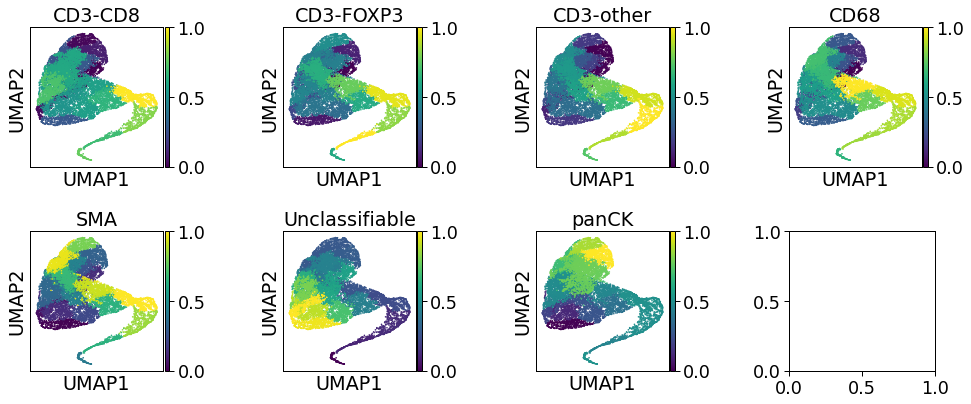

In [42]:
fig, axs = plt.subplots(nrows=2, ncols=4, figsize=(14,6))
axs = axs.flatten()

for i, column in enumerate(scaled_counts_by_cluster.columns):
    sc.pl.umap(ssl_adata_train, color=column, show=False, ax=axs[i])

plt.tight_layout()
# plt.savefig('/Users/Kai/GRI_CRC/UMAP_by_marker.pdf', dpi=300, bbox_inches='tight', pad_inches=.1)
# plt.savefig('/Users/Kai/GRI_CRC/UMAP_by_marker.png', dpi=600, bbox_inches='tight', pad_inches=.1)
plt.show()